# RKLB Stock Prediction — End-to-End Demo

**Rocket Lab USA (RKLB) | Multi-Signal Ensemble Forecast**

This notebook demonstrates a three-layer prediction pipeline:

| Layer | Technique | Purpose |
|-------|-----------|----------|
| 1 | **LightGBM** (ML) | Tabular features: RSI, MACD, Bollinger Bands, ATR, launch events |
| 2 | **LSTM + Multi-Head Attention** (DL) | Temporal sequence modelling over 20-day windows |
| 3 | **FinBERT** (SLM) | Financial NLP sentiment from live news headlines |
| Ensemble | Weighted average + Ridge meta-learner | Combines all signals → 4-day price + BUY/SELL/HOLD |

> Run cells top-to-bottom. First run trains and saves model artifacts; subsequent runs load from disk.

## 0. Setup

In [35]:
# Delete all stale artifacts — feature set changed (target_return leak fixed),
# LGBM now predicts returns, DROPOUT/weight_decay updated. Must retrain everything.
import os
import sys; sys.path.insert(0, os.path.abspath('..'))
from config import ARTIFACTS_DIR, LOOKBACK_DAYS

stale = list(ARTIFACTS_DIR.glob('*.pkl')) + list(ARTIFACTS_DIR.glob('*.pt'))
for f in stale:
    os.remove(f)
    print(f'  Deleted {f.name}')
if not stale:
    print('  artifacts/ already clean')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries loaded.')


  Deleted feature_cols.pkl
  Deleted lgbm_model.pkl
  Deleted meta_learner.pkl
  Deleted scaler.pkl
  Deleted sentiment_cache.pkl
  Deleted lstm_model.pt
Libraries loaded.


## 1. Data Ingestion
Pulls live OHLCV data from yfinance and news from NewsAPI + Yahoo Finance.

In [36]:
from data.fetch_price import load_price_data
from data.fetch_news import load_news
from data.fetch_launches import load_launches

print('Fetching price data...')
price_df = load_price_data()
print(f'  RKLB + NASDAQ: {len(price_df)} trading days ({price_df.index[0].date()} → {price_df.index[-1].date()})')

print('Fetching news...')
news_df = load_news()
print(f'  Headlines: {len(news_df)}')

print('Loading launch data...')
launches_df = load_launches()
print(f'  Electron launches: {len(launches_df)}')

Fetching price data...
  RKLB + NASDAQ: 1045 trading days (2022-04-01 → 2026-06-02)
Fetching news...
  NewsAPI: 34 articles
  yfinance: 0 articles
  Headlines: 33
Loading launch data...
  Electron launches: 88


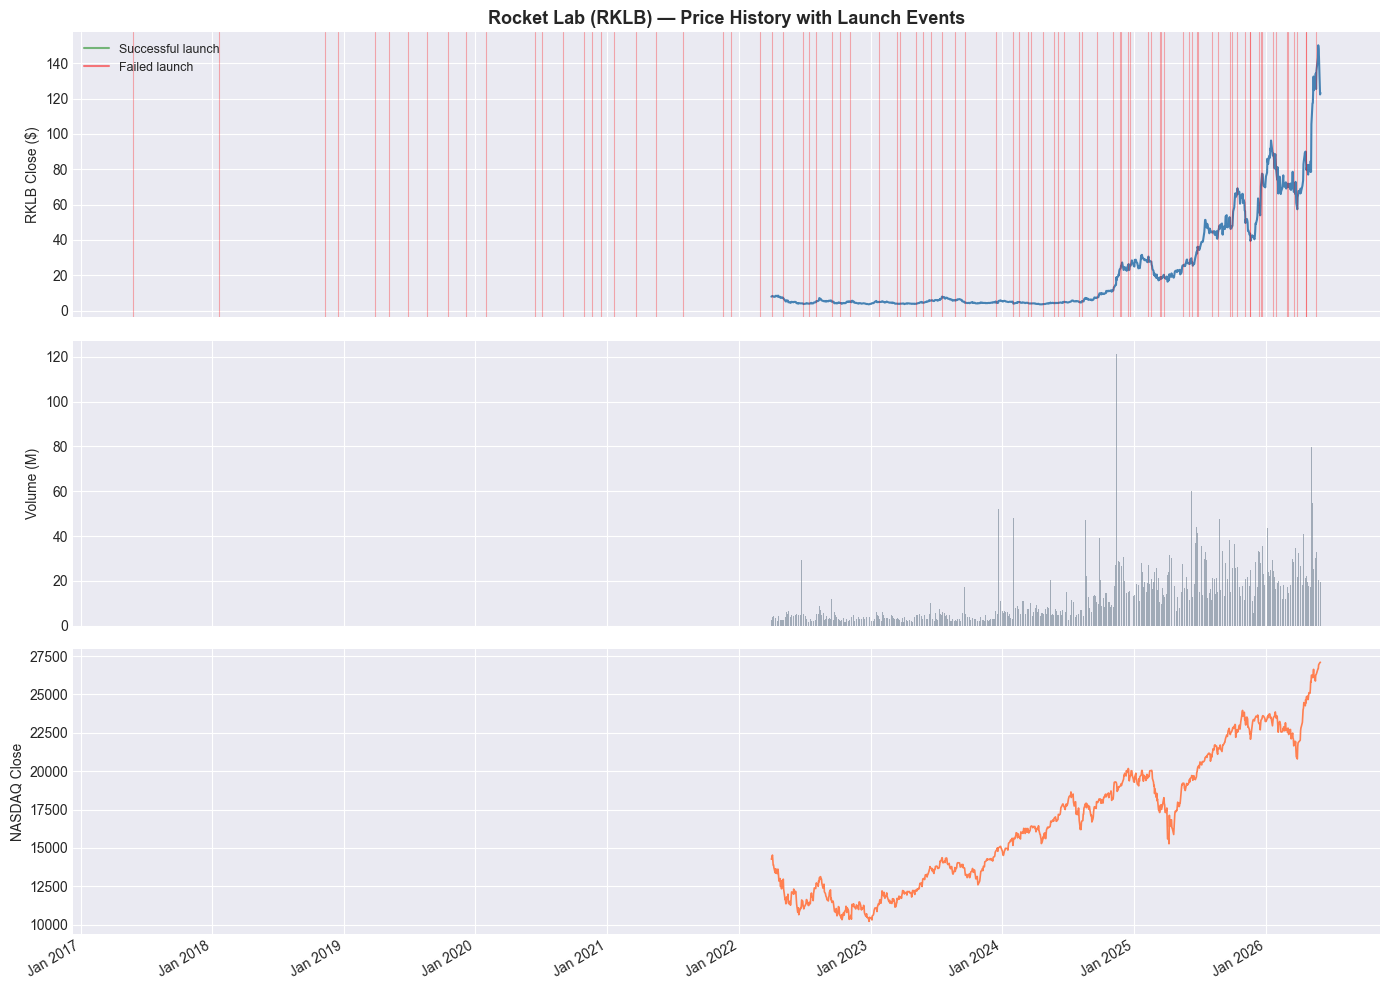

In [37]:
# ── Price history ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(price_df.index, price_df['rklb_close'], color='steelblue', linewidth=1.5)
axes[0].set_ylabel('RKLB Close ($)')
axes[0].set_title('Rocket Lab (RKLB) — Price History with Launch Events', fontsize=13, fontweight='bold')

# Overlay launch events
for _, row in launches_df.iterrows():
    color = 'green' if row['success'] else 'red'
    axes[0].axvline(row['date'], color=color, alpha=0.3, linewidth=0.8)

from matplotlib.lines import Line2D
axes[0].legend(handles=[
    Line2D([0], [0], color='green', alpha=0.5, label='Successful launch'),
    Line2D([0], [0], color='red', alpha=0.5, label='Failed launch'),
], fontsize=9)

axes[1].bar(price_df.index, price_df['rklb_volume'] / 1e6, color='slategray', alpha=0.6, width=1)
axes[1].set_ylabel('Volume (M)')

axes[2].plot(price_df.index, price_df['nasdaq_close'], color='coral', linewidth=1.2, label='NASDAQ')
axes[2].set_ylabel('NASDAQ Close')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [38]:
from models.finbert_sentiment import aggregate_daily_sentiment
from features.preprocess import build_dataset, get_feature_columns, time_split, build_scaler, make_sequences

print('Scoring headlines with FinBERT (cached after first run)...')
sentiment_df = aggregate_daily_sentiment(news_df)
print(f'  Sentiment scores: {len(sentiment_df)} days')

print('Building full feature matrix...')
df = build_dataset(sentiment_df=sentiment_df)
feature_cols = get_feature_columns(df)
print(f'  Shape: {df.shape} | Features: {len(feature_cols)}')

Scoring headlines with FinBERT (cached after first run)...


FinBERT: 100%|██████████| 3/3 [00:02<00:00,  1.11it/s]


  Sentiment scores: 17 days
Building full feature matrix...
  Shape: (992, 45) | Features: 31


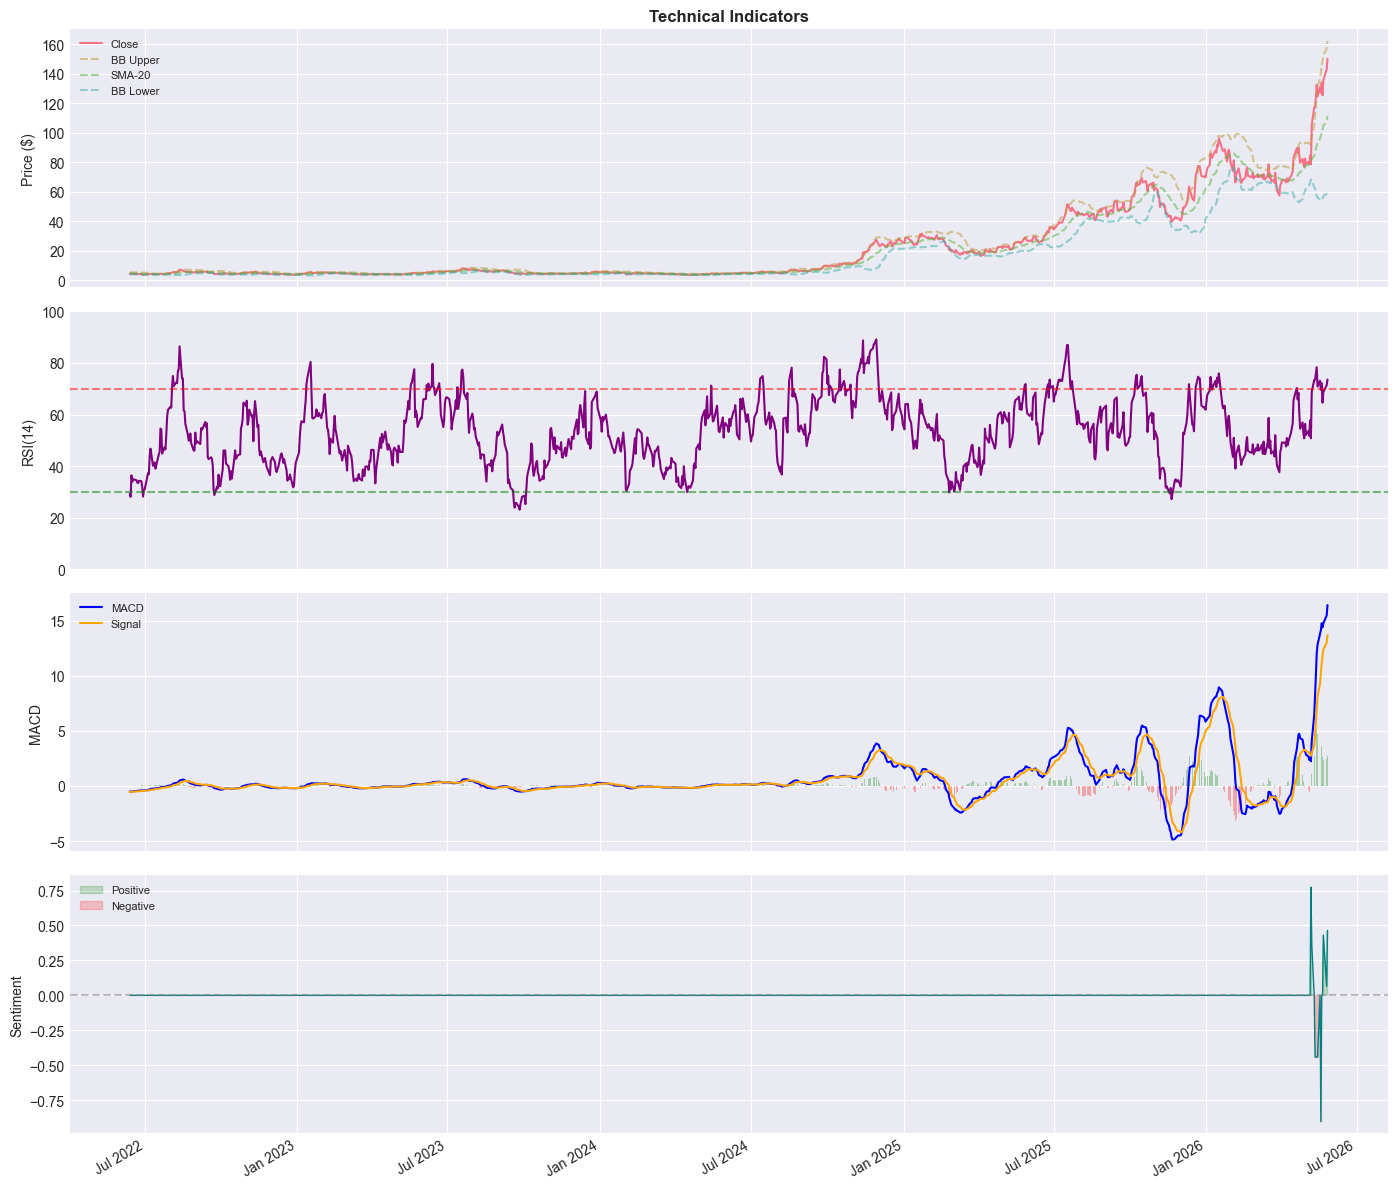

In [39]:
# ── Technical indicators ───────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df['rklb_close'], label='Close', linewidth=1.5)
axes[0].plot(df.index, df['bb_upper'], '--', alpha=0.5, label='BB Upper')
axes[0].plot(df.index, df['sma_20'], '--', alpha=0.5, label='SMA-20')
axes[0].plot(df.index, df['bb_lower'], '--', alpha=0.5, label='BB Lower')
axes[0].set_ylabel('Price ($)')
axes[0].legend(fontsize=8)
axes[0].set_title('Technical Indicators', fontsize=12, fontweight='bold')

axes[1].plot(df.index, df['rsi'], color='purple')
axes[1].axhline(70, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5)
axes[1].set_ylabel('RSI(14)')
axes[1].set_ylim(0, 100)

axes[2].plot(df.index, df['macd'], label='MACD', color='blue')
axes[2].plot(df.index, df['macd_signal'], label='Signal', color='orange')
axes[2].bar(df.index, df['macd_hist'], alpha=0.3, color=np.where(df['macd_hist'] > 0, 'green', 'red'))
axes[2].set_ylabel('MACD')
axes[2].legend(fontsize=8)

axes[3].plot(df.index, df['sentiment_score'], color='teal', linewidth=1)
axes[3].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[3].fill_between(df.index, df['sentiment_score'], 0,
                      where=df['sentiment_score'] > 0, alpha=0.2, color='green', label='Positive')
axes[3].fill_between(df.index, df['sentiment_score'], 0,
                      where=df['sentiment_score'] < 0, alpha=0.2, color='red', label='Negative')
axes[3].set_ylabel('Sentiment')
axes[3].legend(fontsize=8)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 3. Train / Val / Test Split (Time-Aware — No Leakage)

In [40]:
train_df, val_df, test_df = time_split(df)

print(f'Train : {len(train_df):4d} rows  {train_df.index[0].date()} → {train_df.index[-1].date()}')
print(f'Val   : {len(val_df):4d} rows  {val_df.index[0].date()} → {val_df.index[-1].date()}')
print(f'Test  : {len(test_df):4d} rows  {test_df.index[0].date()} → {test_df.index[-1].date()}')

# Scaler fitted on TRAIN only — no leakage
scaler = build_scaler(train_df, feature_cols)
print(f'\nScaler fitted on {len(train_df)} training rows. Saved to artifacts/.')

Train :  723 rows  2022-06-13 → 2025-04-30
Val   :  120 rows  2025-05-01 → 2025-10-21
Test  :  149 rows  2025-10-22 → 2026-05-27

Scaler fitted on 723 training rows. Saved to artifacts/.


## 4. Layer 1 — LightGBM (ML)

In [41]:
from models import lgbm_model
from config import LGBM_MODEL_PATH

if LGBM_MODEL_PATH.exists():
    print('Loading saved LightGBM models...')
    lgbm_models = lgbm_model.load()
else:
    print('Training LightGBM models (walk-forward CV)...')
    lgbm_models = lgbm_model.train(train_df, val_df, feature_cols)

lgbm_test_preds = lgbm_model.predict(lgbm_models, test_df[feature_cols].values,
                                       current_prices=test_df['rklb_close'].values)
lgbm_eval = lgbm_model.evaluate(lgbm_models, test_df, feature_cols,
                                  current_prices=test_df['rklb_close'].values)
print('\nLightGBM — Test Set Performance:')
display(lgbm_eval)

Training LightGBM models (walk-forward CV)...
  LightGBM price_d1 — CV RMSE: 4.508% ± 1.208%
  LightGBM price_d2 — CV RMSE: 6.232% ± 1.367%
  LightGBM price_d3 — CV RMSE: 7.679% ± 1.853%
  LightGBM price_d4 — CV RMSE: 8.850% ± 2.174%
  LightGBM direction — CV Accuracy: 0.530 ± 0.027
  Saved to c:\Users\alexl\Documents\Personal_Projects\rocketlab-stock-prediction\artifacts\lgbm_model.pkl

LightGBM — Test Set Performance:


,horizon,MAE_$,RMSE_$,Accuracy
0,d+1,4.0378,5.3106,NaN
1,d+2,5.3277,7.2973,NaN
2,d+3,7.5120,9.8120,NaN
3,d+4,8.3411,10.9197,NaN
4,direction,NaN,NaN,0.4362


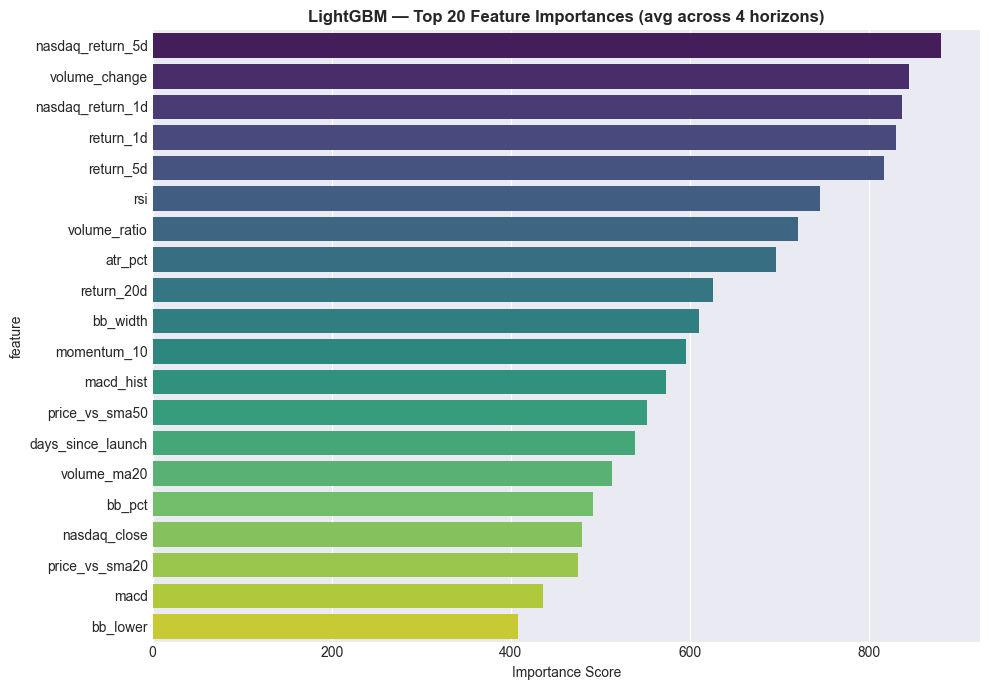

In [42]:
# Feature importance
fi = lgbm_model.feature_importance(lgbm_models, feature_cols)

fig, ax = plt.subplots(figsize=(10, 7))
fi_top = fi.head(20)
sns.barplot(data=fi_top, x='importance', y='feature', ax=ax, palette='viridis')
ax.set_title('LightGBM — Top 20 Feature Importances (avg across 4 horizons)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 5. Layer 2 — LSTM + Multi-Head Attention (DL)

In [43]:
from models import lstm_attention
from config import LSTM_MODEL_PATH, LOOKBACK_DAYS

X_train_seq, yp_train, yd_train = make_sequences(train_df, feature_cols, scaler)
X_val_seq, yp_val, yd_val = make_sequences(val_df, feature_cols, scaler)
X_test_seq, yp_test, yd_test = make_sequences(test_df, feature_cols, scaler)

n_features = X_train_seq.shape[2]

if LSTM_MODEL_PATH.exists():
    print('Loading saved LSTM model...')
    lstm_model = lstm_attention.load(n_features)
else:
    print('Training LSTM + Multi-Head Attention model...')
    lstm_model = lstm_attention.train(X_train_seq, yp_train, yd_train, X_val_seq, yp_val, yd_val)

test_current_prices = test_df["rklb_close"].values[LOOKBACK_DAYS:]
lstm_test_preds = lstm_attention.predict(lstm_model, X_test_seq,
                                         current_prices=test_current_prices)
lstm_eval = lstm_attention.evaluate(lstm_model, X_test_seq, yp_test, yd_test,
                                    current_prices=test_current_prices)
print('\nLSTM + Attention — Test Set Performance:')
display(lstm_eval)

Training LSTM + Multi-Head Attention model...
  Epoch  10 | train=0.2122 val=0.2376 lr=0.001000
  Epoch  20 | train=0.2045 val=0.2352 lr=0.001000
  Epoch  30 | train=0.1872 val=0.2664 lr=0.000500
  Early stopping at epoch 35
  Best val loss: 0.2130 — saved to c:\Users\alexl\Documents\Personal_Projects\rocketlab-stock-prediction\artifacts\lstm_model.pt

LSTM + Attention — Test Set Performance:


,horizon,MAE_$,RMSE_$,Accuracy
0,d+1,3.8090,5.1122,NaN
1,d+2,4.9160,6.9117,NaN
2,d+3,6.6630,9.0757,NaN
3,d+4,7.7338,10.5121,NaN
4,direction,NaN,NaN,0.5814


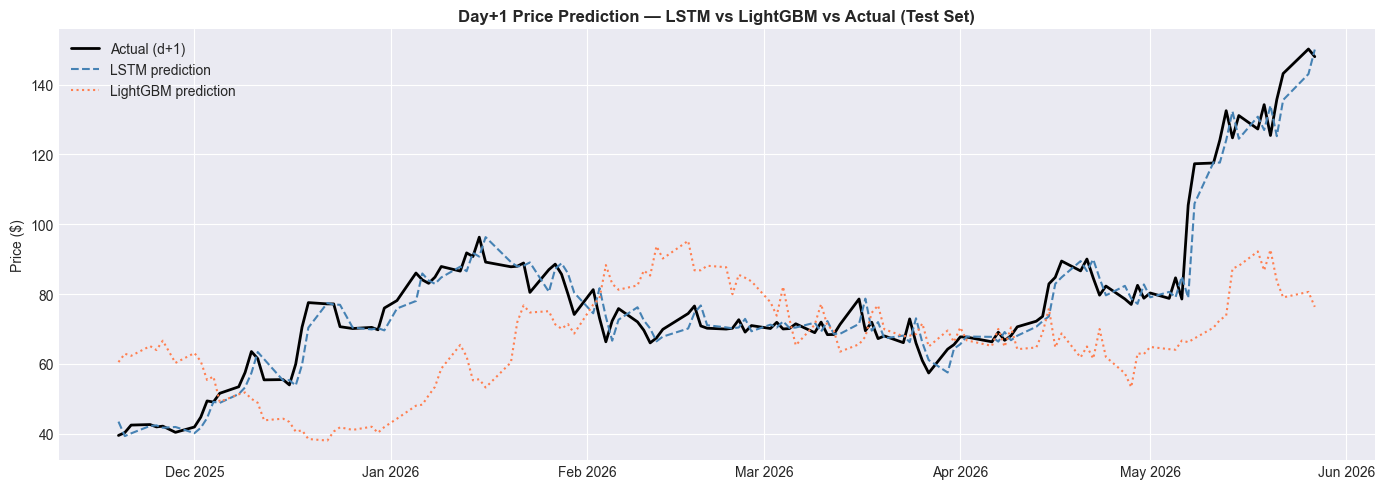

In [44]:
# LSTM prediction vs actual on test set
test_dates = test_df.index[LOOKBACK_DAYS:]  # account for lookback window
actual_d1 = test_current_prices * (1 + yp_test[:, 0])  # convert returns to dollars
lstm_pred_d1 = lstm_test_preds['prices'][:, 0]
lgbm_pred_d1 = lgbm_test_preds['prices'][:len(test_dates), 0]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, actual_d1, label='Actual (d+1)', linewidth=2, color='black')
ax.plot(test_dates, lstm_pred_d1, label='LSTM prediction', linewidth=1.5, linestyle='--', color='steelblue')
ax.plot(test_dates[:len(lgbm_pred_d1)], lgbm_pred_d1, label='LightGBM prediction', linewidth=1.5, linestyle=':', color='coral')
ax.set_title('Day+1 Price Prediction — LSTM vs LightGBM vs Actual (Test Set)', fontweight='bold')
ax.set_ylabel('Price ($)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Ensemble — Combining All Signals

In [45]:
from ensemble.ensemble import weighted_predict, train_meta_learner, meta_predict, evaluate as ensemble_evaluate
from config import META_LEARNER_PATH, LOOKBACK_DAYS

# Align test sentiment scores with test sequence rows
test_sentiment = test_df['sentiment_score'].values[LOOKBACK_DAYS:]  # match sequence length

# LightGBM predicts on all test rows; LSTM uses a lookback so it produces fewer rows.
# Trim LGBM to the tail so both arrays have the same length before blending.
n_seq = len(lstm_test_preds["prices"])
lgbm_test_preds_aligned = {
    "prices": lgbm_test_preds["prices"][-n_seq:],
    "direction": lgbm_test_preds["direction"][-n_seq:],
}

# Weighted ensemble
weighted_preds = weighted_predict(lgbm_test_preds_aligned, lstm_test_preds,
                                   sentiment_scores=test_sentiment,
                                   current_prices=test_current_prices)

# Meta-learner (train on val predictions if not saved)
if not META_LEARNER_PATH.exists():
    lgbm_val_preds = lgbm_model.predict(lgbm_models, val_df[feature_cols].values,
                                          current_prices=val_df['rklb_close'].values)
    val_current_prices = val_df['rklb_close'].values[LOOKBACK_DAYS:]
    lstm_val_preds = lstm_attention.predict(lstm_model, X_val_seq, current_prices=val_current_prices)
    n_val_seq = len(lstm_val_preds["prices"])
    lgbm_val_preds_aligned = {
        "prices": lgbm_val_preds["prices"][-n_val_seq:],
        "direction": lgbm_val_preds["direction"][-n_val_seq:],
    }
    val_sentiment = val_df['sentiment_score'].values[LOOKBACK_DAYS:]
    yp_val_dollars = val_current_prices[:, np.newaxis] * (1 + yp_val)  # convert returns to dollars
    train_meta_learner(lgbm_val_preds_aligned, lstm_val_preds, yp_val_dollars, yd_val, val_sentiment)

meta_preds = meta_predict(lgbm_test_preds_aligned, lstm_test_preds,
                          sentiment_scores=test_sentiment,
                          current_prices=test_current_prices)

# Convert test targets to dollars for scale-consistent evaluation (Bug #9)
yp_test_dollars = test_current_prices[:, np.newaxis] * (1 + yp_test)

print('Weighted Ensemble — Test Set Performance:')
display(ensemble_evaluate(weighted_preds, yp_test_dollars, yd_test))

print('\nMeta-Learner Ensemble — Test Set Performance:')
display(ensemble_evaluate(meta_preds, yp_test_dollars, yd_test))


  Meta-learner saved to c:\Users\alexl\Documents\Personal_Projects\rocketlab-stock-prediction\artifacts\meta_learner.pkl
Weighted Ensemble — Test Set Performance:


,horizon,MAE_$,RMSE_$,Accuracy
0,d+1,5.0789,6.6004,NaN
1,d+2,5.7631,7.9988,NaN
2,d+3,7.4842,10.2309,NaN
3,d+4,7.7929,10.9580,NaN
4,direction,NaN,NaN,0.4496



Meta-Learner Ensemble — Test Set Performance:


,horizon,MAE_$,RMSE_$,Accuracy
0,d+1,4.3054,5.6000,NaN
1,d+2,5.7462,7.7383,NaN
2,d+3,8.1139,10.4013,NaN
3,d+4,8.7808,11.4296,NaN
4,direction,NaN,NaN,0.4419


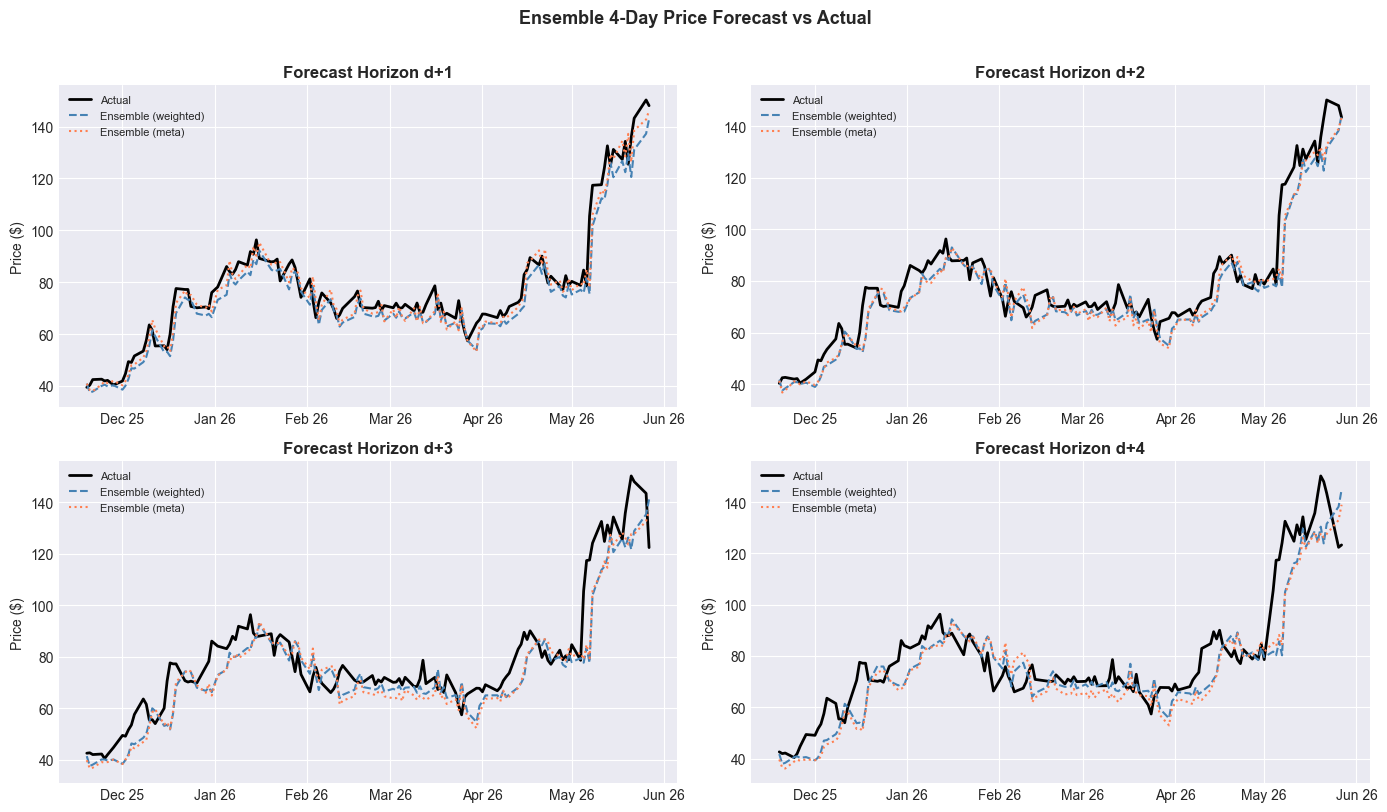

In [46]:
# 4-day forecast comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
horizons = ['d+1', 'd+2', 'd+3', 'd+4']

for i, (ax, h_label) in enumerate(zip(axes.flatten(), horizons)):
    ax.plot(test_dates, yp_test_dollars[:, i], label='Actual', color='black', linewidth=2)
    ax.plot(test_dates, weighted_preds['prices'][:, i], label='Ensemble (weighted)', linestyle='--', color='steelblue')
    ax.plot(test_dates, meta_preds['prices'][:, i], label='Ensemble (meta)', linestyle=':', color='coral')
    ax.set_title(f'Forecast Horizon {h_label}', fontweight='bold')
    ax.set_ylabel('Price ($)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.legend(fontsize=8)

plt.suptitle('Ensemble 4-Day Price Forecast vs Actual', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Directional Signal — BUY / SELL / HOLD

Directional Classification Report (Ensemble):
              precision    recall  f1-score   support

        DOWN       0.38      0.45      0.41        56
          UP       0.51      0.44      0.47        73

    accuracy                           0.44       129
   macro avg       0.44      0.44      0.44       129
weighted avg       0.45      0.44      0.44       129



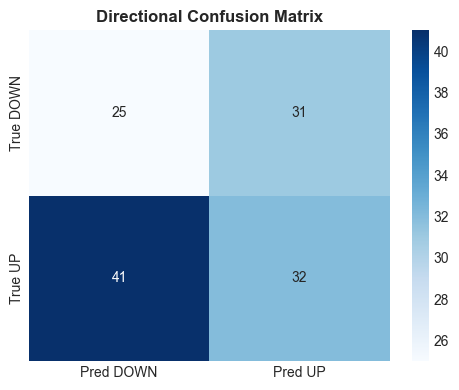

In [47]:
# Directional accuracy breakdown
from sklearn.metrics import classification_report, confusion_matrix

dir_pred = (meta_preds['direction'] > 0.5).astype(int)
dir_true = yd_test[:len(dir_pred)]

print('Directional Classification Report (Ensemble):')
print(classification_report(dir_true, dir_pred, target_names=['DOWN', 'UP']))

cm = confusion_matrix(dir_true, dir_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred DOWN', 'Pred UP'],
            yticklabels=['True DOWN', 'True UP'])
ax.set_title('Directional Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

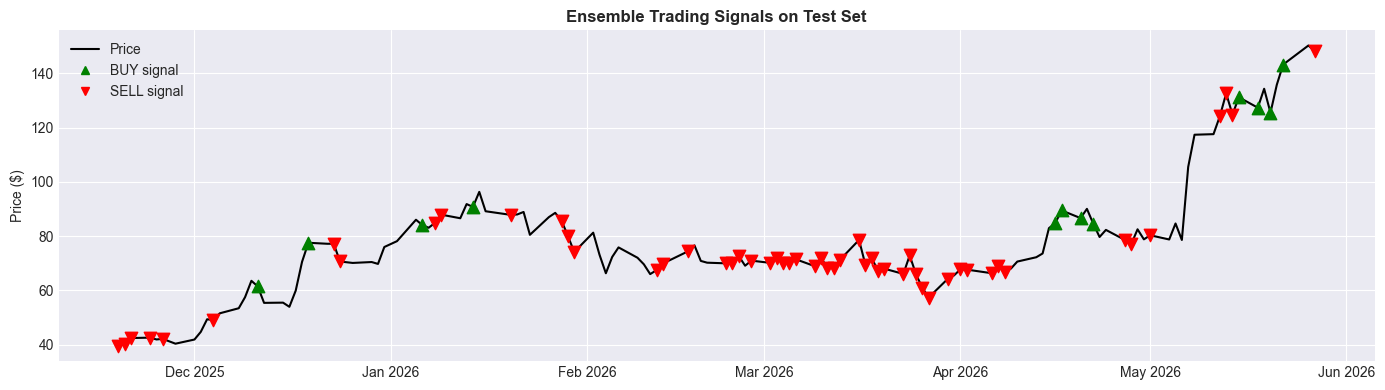

In [48]:
# Signal timeline
signal_colors = {'BUY': 'green', 'SELL': 'red', 'HOLD': 'gray'}
signals = meta_preds['signal']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_dates, yp_test_dollars[:, 0], color='black', linewidth=1.5, label='Price (d+1 actual)')

for date, sig, price in zip(test_dates, signals, yp_test_dollars[:, 0]):
    if sig != 'HOLD':
        ax.scatter(date, price, color=signal_colors[sig], zorder=5,
                   marker='^' if sig == 'BUY' else 'v', s=80)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='black', label='Price'),
    Line2D([0], [0], marker='^', color='green', linestyle='None', label='BUY signal'),
    Line2D([0], [0], marker='v', color='red', linestyle='None', label='SELL signal'),
])
ax.set_title('Ensemble Trading Signals on Test Set', fontweight='bold')
ax.set_ylabel('Price ($)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

## 8. Live Inference — Next 4 Days

In [49]:
from datetime import datetime, timedelta

# Use the most recent LOOKBACK_DAYS trading days as input
latest_df = df.iloc[-LOOKBACK_DAYS:]
X_live = scaler.transform(latest_df[feature_cols])
X_live_seq = X_live[np.newaxis, :, :]  # shape (1, 60, n_features)
X_live_tab = latest_df[feature_cols].values[-1:]

current_price = df['rklb_close'].iloc[-1]

lgbm_live = lgbm_model.predict(lgbm_models, X_live_tab, current_prices=np.array([current_price]))
lstm_live = lstm_attention.predict(lstm_model, X_live_seq,
                                    current_prices=np.array([current_price]))
sent_live = np.array([latest_df['sentiment_score'].iloc[-1]])

live_preds = meta_predict(lgbm_live, lstm_live, sentiment_scores=sent_live,
                          current_prices=np.array([current_price]))

today = df.index[-1]
trading_days = pd.bdate_range(start=today + timedelta(days=1), periods=4)

print(f'\nCurrent RKLB price (as of {today.date()}): ${current_price:.2f}')
print(f'Current sentiment score: {sent_live[0]:+.3f}')
print(f'\n{"Date":12} {"Predicted ($)":>14} {"Δ from today":>14} {"Signal":>8}')
print('-' * 55)
for i, (day, price) in enumerate(zip(trading_days, live_preds['prices'][0])):
    delta = price - current_price
    direction = live_preds['direction'][0]
    sig = live_preds['signal'][0]
    print(f'{str(day.date()):12} ${price:>12.2f} {delta:>+13.2f} {sig if i == 0 else "":>8}')



Current RKLB price (as of 2026-05-27): $150.23
Current sentiment score: +0.465

Date          Predicted ($)   Δ from today   Signal
-------------------------------------------------------
2026-05-28   $      146.13         -4.10     SELL
2026-05-29   $      143.36         -6.87         
2026-06-01   $      136.77        -13.46         
2026-06-02   $      139.00        -11.23         


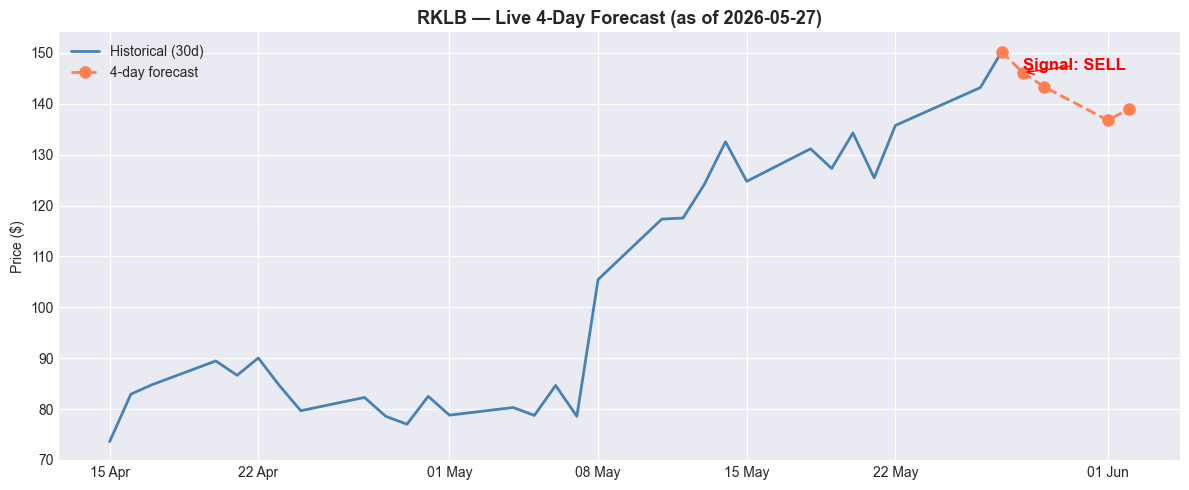

In [50]:
# Live forecast chart
history_window = df['rklb_close'].iloc[-30:]
pred_prices = live_preds['prices'][0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_window.index, history_window.values, color='steelblue', linewidth=2, label='Historical (30d)')

# Bridge from last known price
bridge_x = [history_window.index[-1]] + list(trading_days)
bridge_y = [current_price] + list(pred_prices)
ax.plot(bridge_x, bridge_y, color='coral', linewidth=2, linestyle='--', marker='o', markersize=8, label='4-day forecast')

signal = live_preds['signal'][0]
signal_color = {'BUY': 'green', 'SELL': 'red', 'HOLD': 'gray'}[signal]
ax.annotate(f'Signal: {signal}', xy=(trading_days[0], pred_prices[0]),
            xytext=(trading_days[0], pred_prices[0] + 0.5),
            fontsize=12, fontweight='bold', color=signal_color,
            arrowprops=dict(arrowstyle='->', color=signal_color))

ax.set_title(f'RKLB — Live 4-Day Forecast (as of {today.date()})', fontweight='bold', fontsize=13)
ax.set_ylabel('Price ($)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.show()

## 9. Model Performance Summary

In [51]:
summary = pd.DataFrame([
    {'Model': 'LightGBM', 'Type': 'ML', 'MAE d+1 ($)': lgbm_eval.iloc[0]['MAE_$'], 'RMSE d+1 ($)': lgbm_eval.iloc[0]['RMSE_$']},
    {'Model': 'LSTM + MH Attention', 'Type': 'DL', 'MAE d+1 ($)': lstm_eval.iloc[0]['MAE_$'], 'RMSE d+1 ($)': lstm_eval.iloc[0]['RMSE_$']},
    {'Model': 'Ensemble (weighted)', 'Type': 'Ensemble', 'MAE d+1 ($)': ensemble_evaluate(weighted_preds, yp_test_dollars, yd_test).iloc[0]['MAE_$'],
     'RMSE d+1 ($)': ensemble_evaluate(weighted_preds, yp_test_dollars, yd_test).iloc[0]['RMSE_$']},
    {'Model': 'Ensemble (meta-learner)', 'Type': 'Ensemble', 'MAE d+1 ($)': ensemble_evaluate(meta_preds, yp_test_dollars, yd_test).iloc[0]['MAE_$'],
     'RMSE d+1 ($)': ensemble_evaluate(meta_preds, yp_test_dollars, yd_test).iloc[0]['RMSE_$']},
])
display(summary.style.highlight_min(subset=['MAE d+1 ($)', 'RMSE d+1 ($)'], color='lightgreen'))

print(f"\nDirectional accuracy (ensemble): {ensemble_evaluate(meta_preds, yp_test_dollars, yd_test).iloc[-1].get('Accuracy', 'N/A')}")

,Model,Type,MAE d+1 ($),RMSE d+1 ($)
0,LightGBM,ML,4.037800,5.310600
1,LSTM + MH Attention,DL,3.809000,5.112200
2,Ensemble (weighted),Ensemble,5.078900,6.600400
3,Ensemble (meta-learner),Ensemble,4.305400,5.600000



Directional accuracy (ensemble): 0.4419
